### Прогноз цен на авиабилеты

Авиакомпания — это компания, предоставляющая услуги воздушных перевозок пассажиров и грузов. Авиакомпании используют самолеты для предоставления этих услуг и могут заключать партнерские соглашения или альянсы с другими авиакомпаниями в рамках соглашений о код-шеринге, согласно которым они обе предлагают и выполняют один и тот же рейс. Как правило, авиакомпании признаются на основании сертификата или лицензии на осуществление воздушных перевозок, выданной государственным авиационным органом. Авиакомпании могут быть регулярными или чартерными операторами.

Авиакомпании устанавливают цены на свои услуги, стремясь максимизировать прибыль. Ценообразование авиабилетов с годами стало значительно сложнее и в настоящее время в значительной степени определяется компьютеризированными системами управления доходностью.

Цена авиабилета зависит от ряда факторов, таких как продолжительность полета, количество дней до вылета, время прибытия и отправления и т. д. Авиакомпании могут снижать стоимость в моменты, когда им необходимо нарастить спрос, и в моменты, когда билеты менее доступны. Они также могут максимизировать затраты. Цена может зависеть от различных факторов. Каждый фактор имеет свои собственные правила и алгоритмы для установления соответствующей цены. Последние достижения в области искусственного интеллекта (ИИ) и машинного обучения (МО) позволяют выводить такие правила и моделировать изменение цены.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Загрузка данных

In [2]:
df = pd.read_csv("Clean_Dataset.csv", index_col=0)

In [3]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Описание набора данных

* **Airline** (Авиакомпания): Название авиакомпании хранится в столбце «Авиакомпания». Это категория, включающая 6 различных авиакомпаний.
* **Flight** (Рейс): Flight хранит информацию о коде рейса самолета. Это категориальный признак.
* **Source City** (Город-источник): Город, из которого вылетает самолет. Это категория, включающая 6 уникальных городов.
* **Departure Time** (Время отправления): это производная категориальная характеристика, полученная путем группировки временных периодов в интервалы. Она хранит информацию о времени отправления и имеет 6 уникальных временных меток.
* **Stops** (Остановки):Категориальный признак с тремя различными значениями, хранящий количество остановок между городами отправления и назначения.
* **Arrival Time** (Время прибытия): это производная категориальная характеристика, созданная путем группировки временных интервалов в интервалы. Она имеет шесть различных временных меток и содержит информацию о времени прибытия.
* **Destination City** (Город назначения): Город, где приземлится самолет. Это категория, включающая 6 уникальных городов.
* **Class** (Класс): Категориальный признак, содержащий информацию о классе места; имеет два различных значения: Бизнес и Эконом.
* **Duration** (Продолжительность): Непрерывный параметр, отображающий общее время, необходимое для поездки между городами в часах.
* **Days Left** (Осталось дней): это производная характеристика, которая рассчитывается путем вычитания даты поездки из даты бронирования.
* **Price** (Цена): Целевая переменная хранит информацию о цене билета.
не билета.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [5]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [6]:
df.describe(include='O')

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


## Разведочный анализ данных (РАД, EDA)

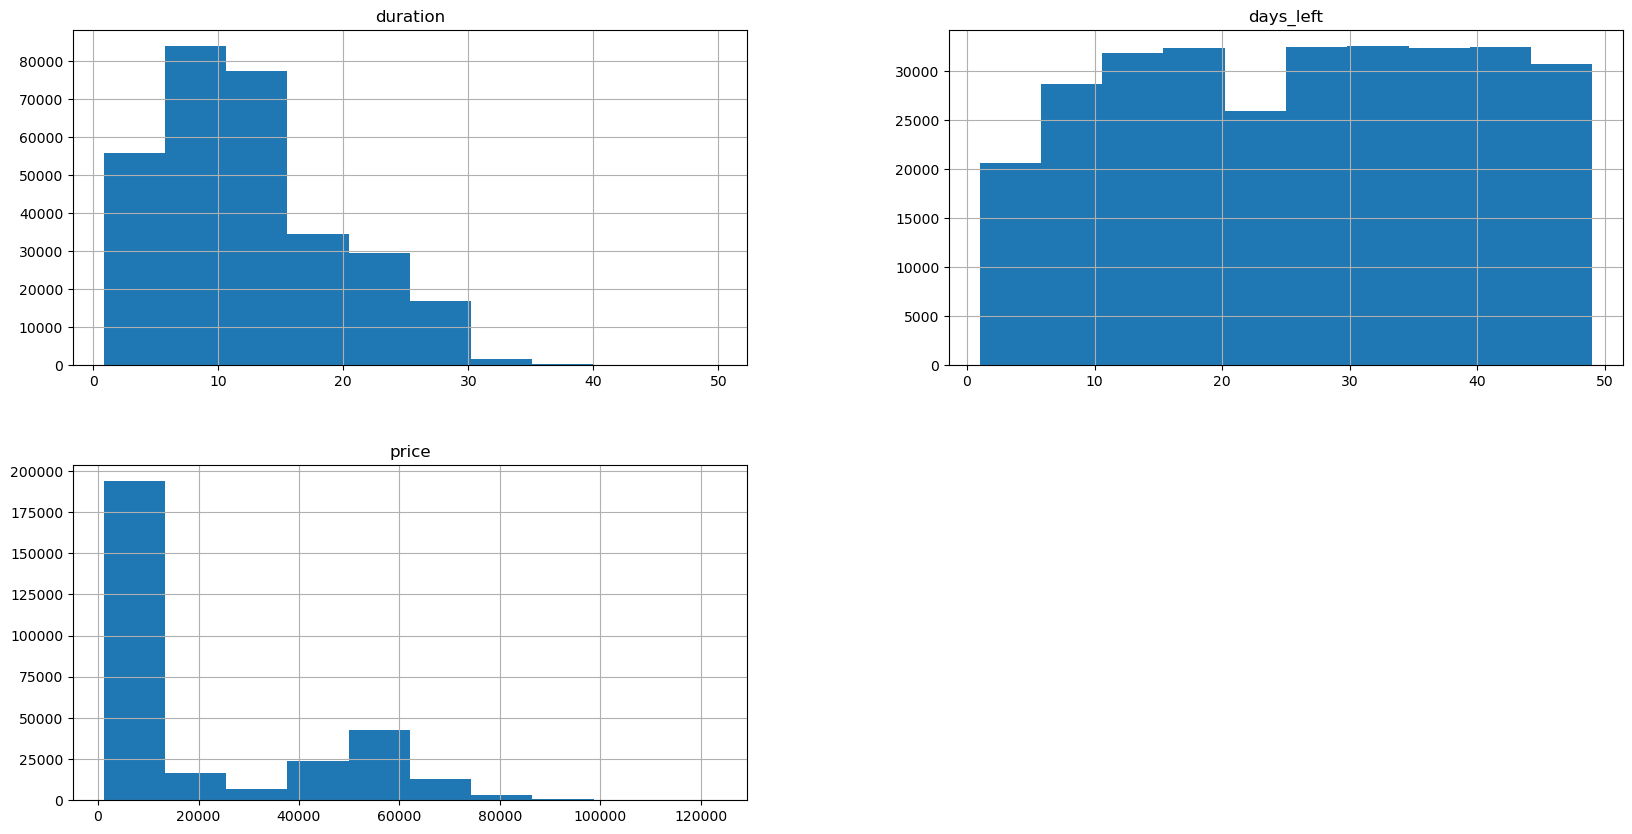

In [7]:
df.hist(figsize=(20,10));

In [8]:
cat_features = [column for column in df.columns if df[column].dtype =="object"]

In [9]:
cat_features

['airline',
 'flight',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class']

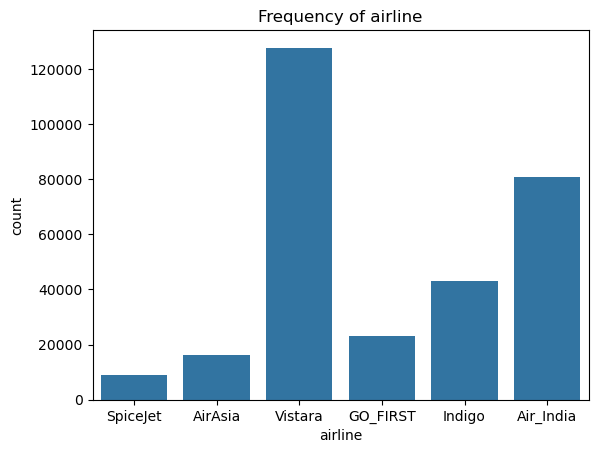

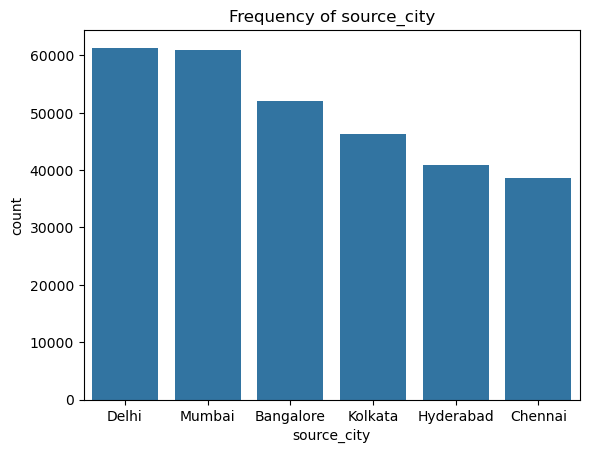

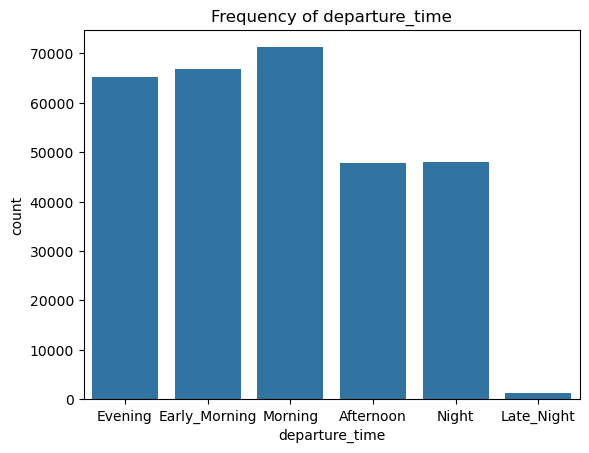

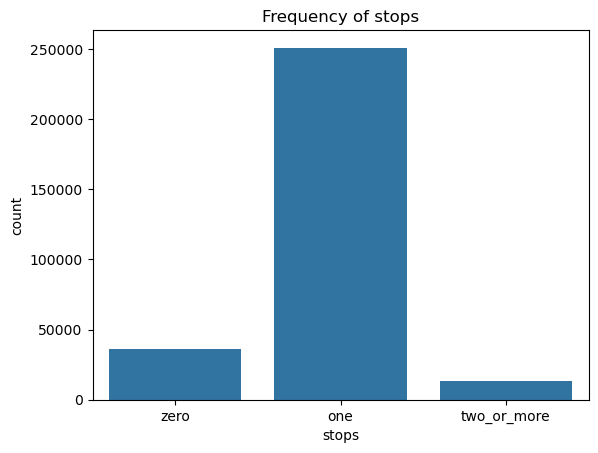

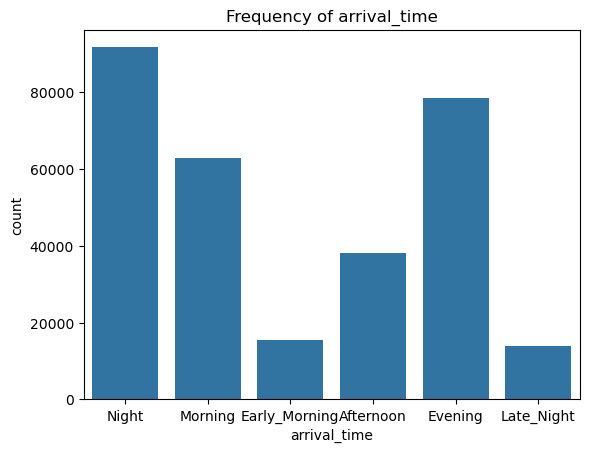

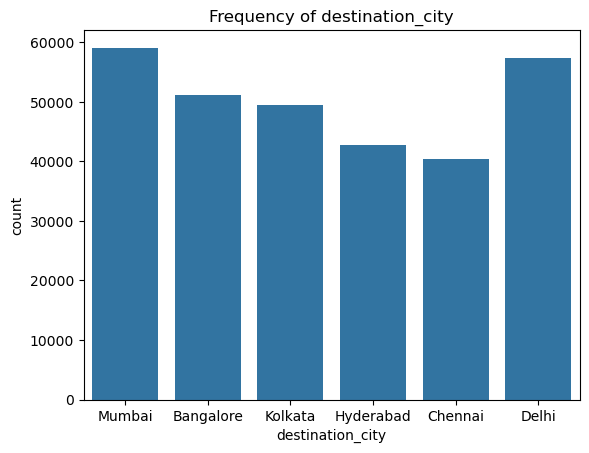

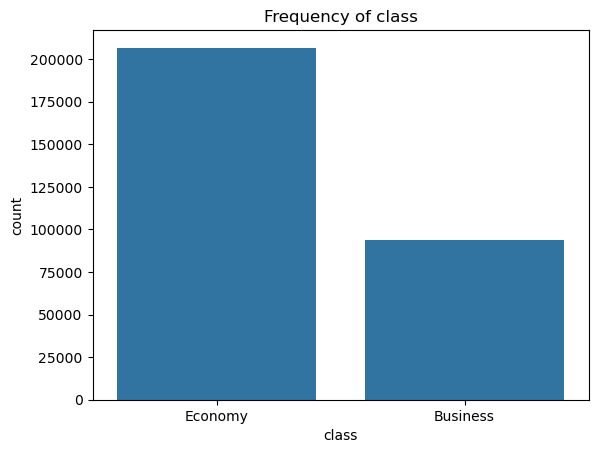

In [10]:
for column in cat_features:
    if column != 'flight':
        sns.countplot(x=df[column], data=df)
        plt.title("Frequency of " + column)
        plt.show()

In [11]:
df[df['flight']=='SG-8709']

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
274,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,3,6060
398,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,4,5953
564,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,5,5953
739,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,6,5953
...,...,...,...,...,...,...,...,...,...,...,...
42049,SpiceJet,SG-8709,Delhi,Evening,one,Early_Morning,Chennai,Economy,13.08,43,4942
42053,SpiceJet,SG-8709,Delhi,Evening,one,Night,Chennai,Economy,26.42,43,4942
42228,SpiceJet,SG-8709,Delhi,Evening,one,Night,Chennai,Economy,26.83,44,4942
42381,SpiceJet,SG-8709,Delhi,Evening,one,Night,Chennai,Economy,27.00,45,4942


In [12]:
df[df['flight']=='SG-8709'].head(20)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
274,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,3,6060
398,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,4,5953
564,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,5,5953
739,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,6,5953
919,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,7,5953
1105,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,8,5953
1331,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,9,6060
1493,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,10,6270
1644,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,11,5953


In [13]:
df1=df.groupby(['flight','airline'],as_index=False).count()
df1.airline.value_counts()

airline
Indigo       704
Air_India    218
GO_FIRST     205
SpiceJet     186
Vistara      133
AirAsia      115
Name: count, dtype: int64

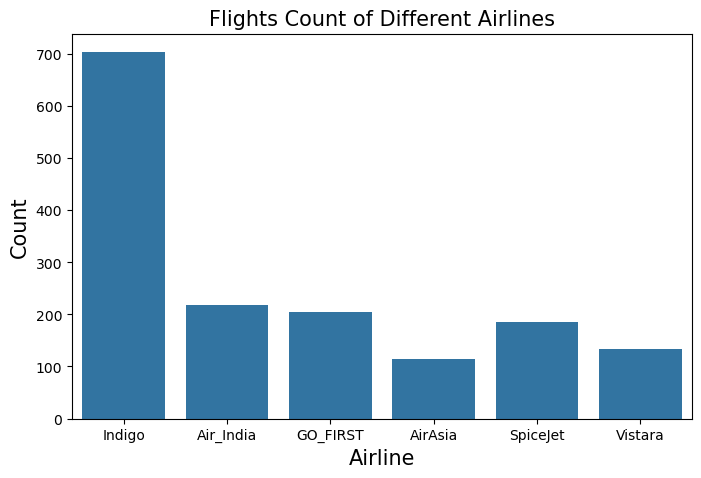

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x=df1['airline'])
plt.title('Flights Count of Different Airlines',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.show()

Индиго одна из самых популярных авиакомпаний.

In [15]:
df2=df.groupby(['flight','airline','class'],as_index=False).count()
df2['class'].value_counts()

class
Economy     1560
Business     295
Name: count, dtype: int64

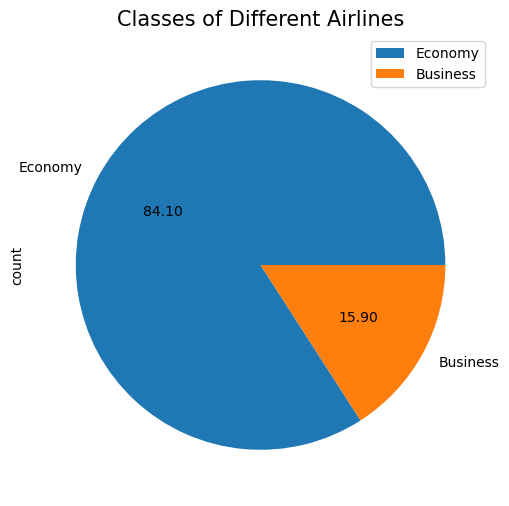

In [16]:
plt.figure(figsize=(8,6))
df2['class'].value_counts().plot(kind='pie',textprops={'color':'black'},autopct='%.2f')
plt.title('Classes of Different Airlines',fontsize=15)
plt.legend(['Economy','Business'])
plt.show()

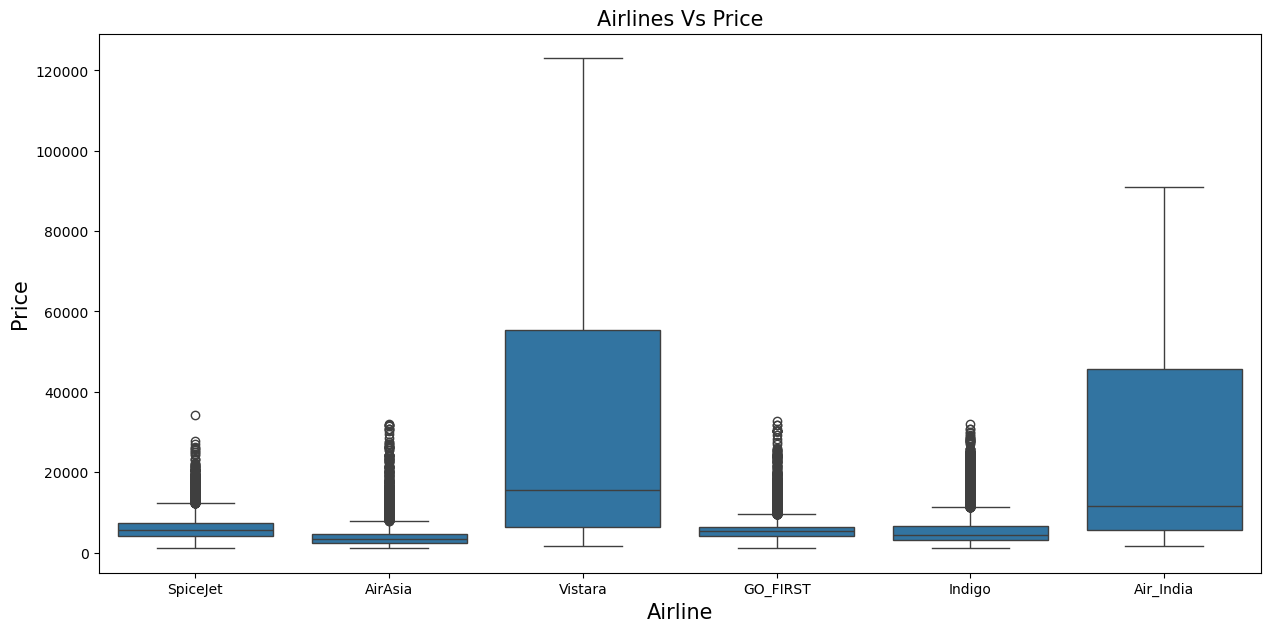

In [17]:
plt.figure(figsize=(15,7))
sns.boxplot(x=df['airline'],y=df['price'])
plt.title('Airlines Vs Price',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

Авиакомпании Vistara и Air India предлагают самые высокие цены по сравнению с другими. У SpiceJet, AirAsia, GO_First и Indigo цены примерно одинаковые.

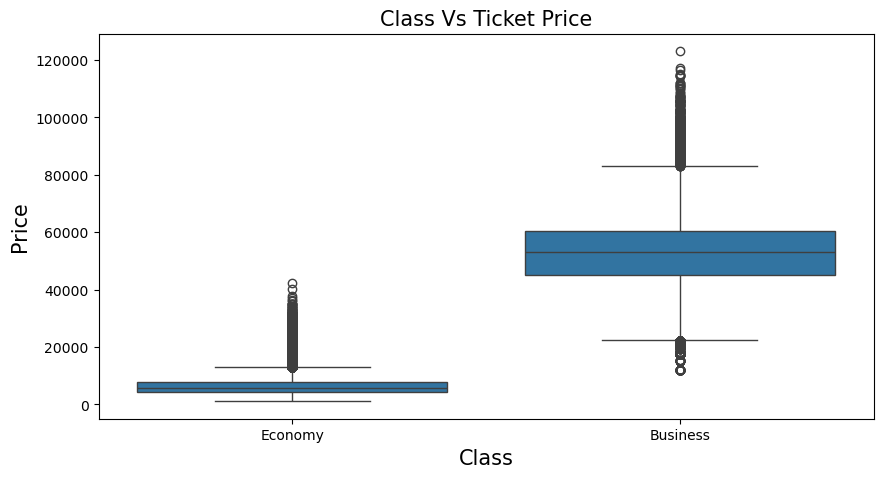

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(x='class',y='price',data=df)
plt.title('Class Vs Ticket Price',fontsize=15)
plt.xlabel('Class',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

Цена билета в бизнес-классе выше, чем в эконом-классе.

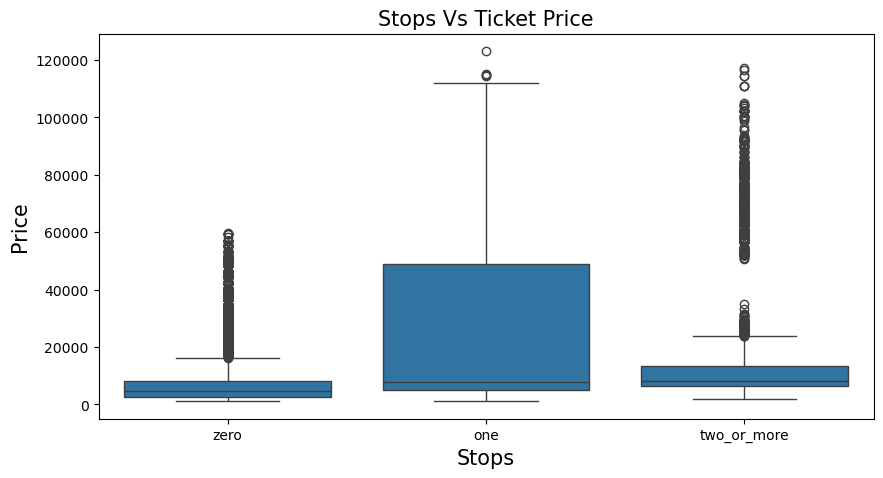

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x='stops',y='price',data=df)
plt.title('Stops Vs Ticket Price',fontsize=15)
plt.xlabel('Stops',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

На рейсах с одной пересадкой действует максимальная цена билета.

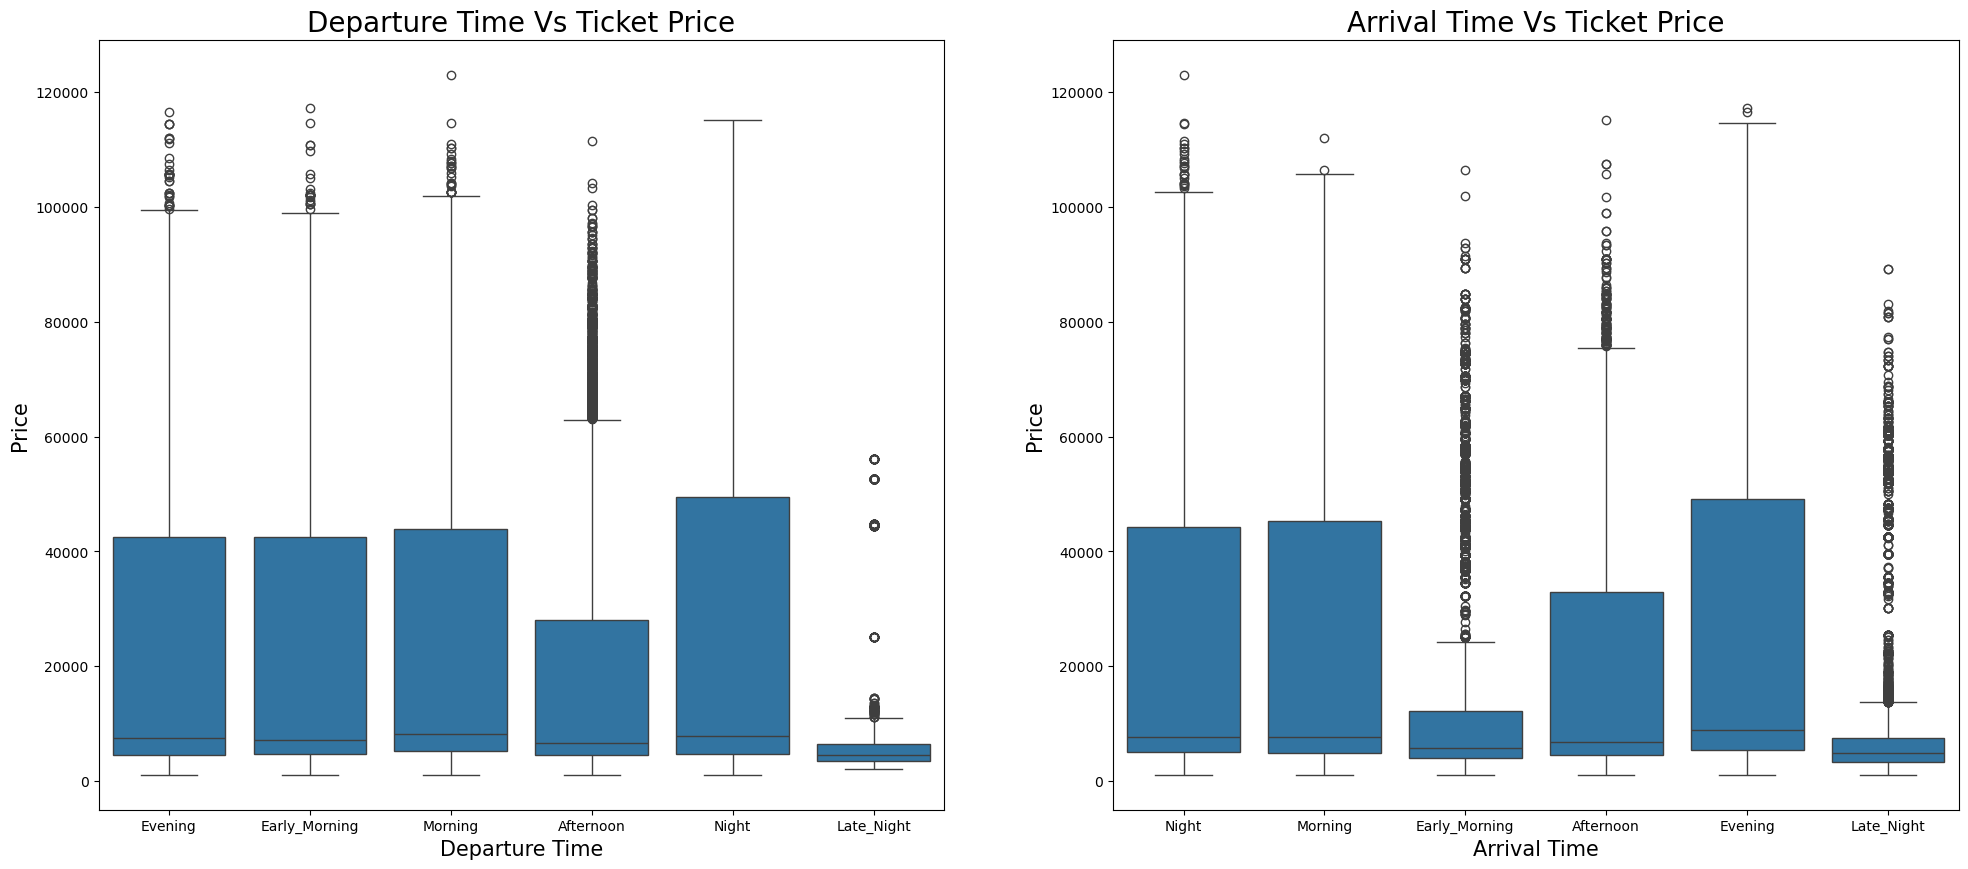

In [20]:
plt.figure(figsize=(24,10))
plt.subplot(1,2,1)
sns.boxplot(x='departure_time',y='price',data=df)
plt.title('Departure Time Vs Ticket Price',fontsize=20)
plt.xlabel('Departure Time',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.subplot(1,2,2)
sns.boxplot(x='arrival_time',y='price',data=df)
plt.title('Arrival Time Vs Ticket Price',fontsize=20)
plt.xlabel('Arrival Time',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

Стоимость билетов на рейсы, вылетающие ночью, выше.
Стоимость билетов практически одинакова для рейсов с вылетом рано утром, утром и вечером.
Низкие цены на билеты на рейсы с поздним ночным вылетом.

Стоимость билетов на рейсы с прибытием вечером выше.
Стоимость билетов практически одинакова для рейсов, прибывающих утром и вечером.
Стоимость билетов низкая на рейсы с поздним ночным временем прибытия, совпадающим со временем отправления.

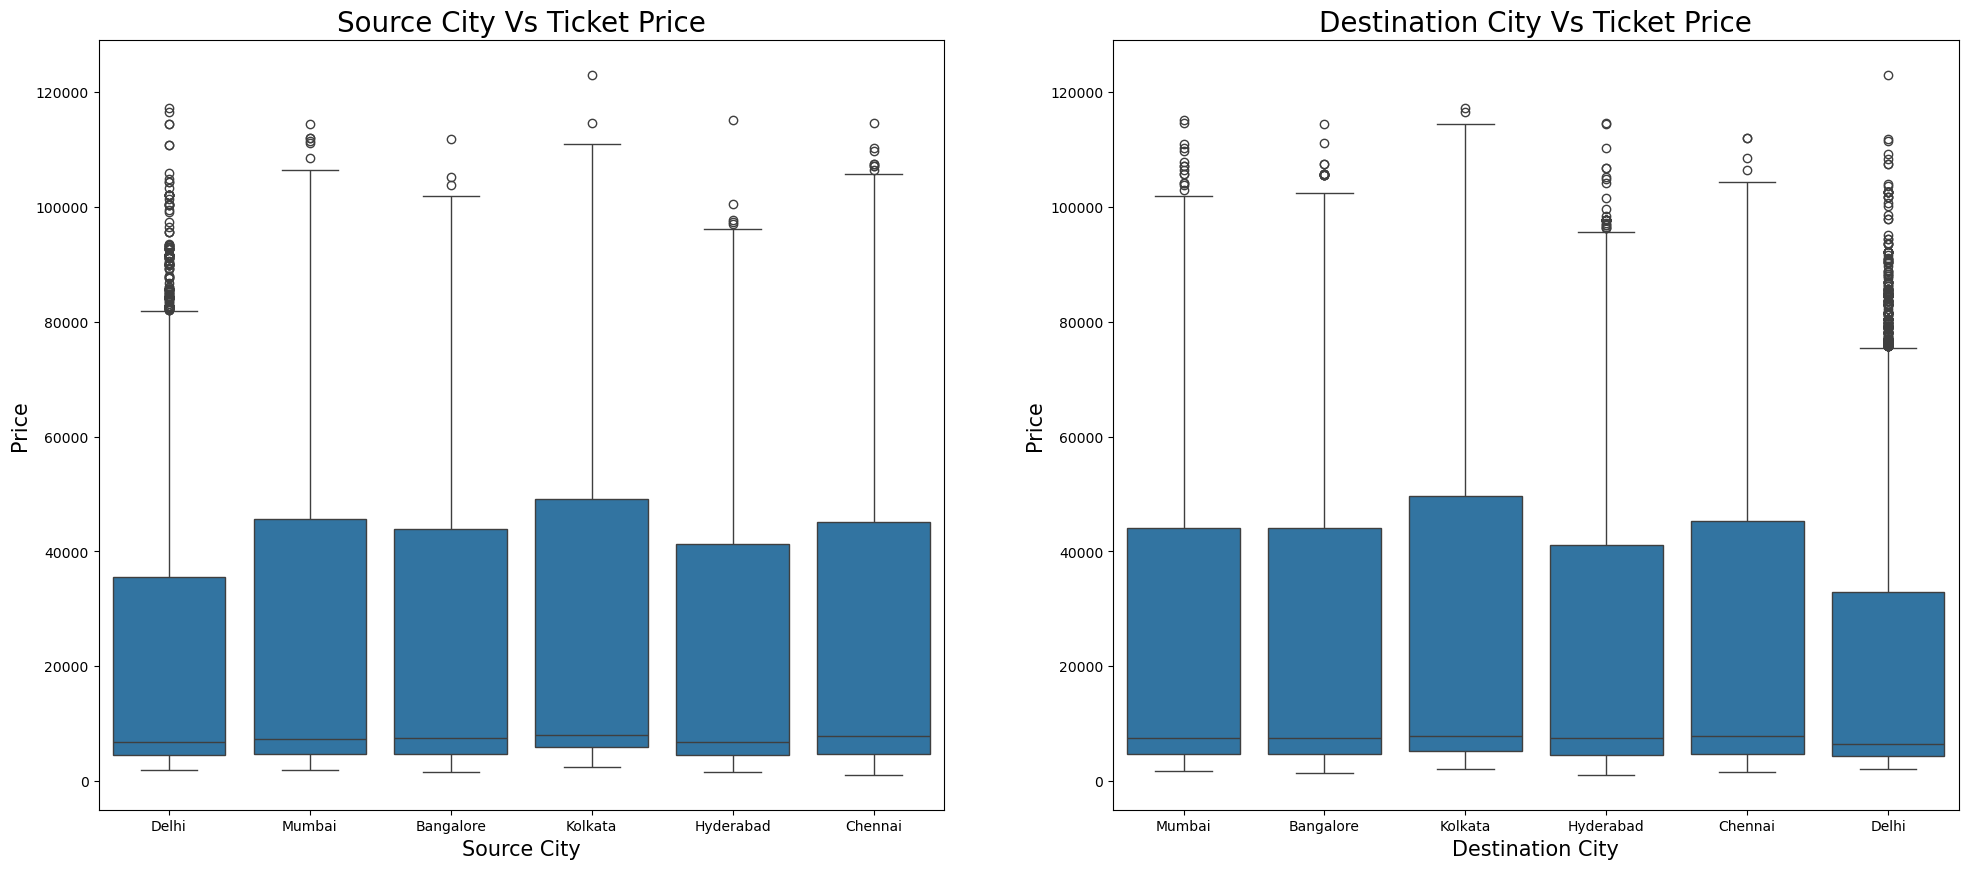

In [21]:
plt.figure(figsize=(24,10))
plt.subplot(1,2,1)
sns.boxplot(x='source_city',y='price',data=df)
plt.title('Source City Vs Ticket Price',fontsize=20)
plt.xlabel('Source City',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.subplot(1,2,2)
sns.boxplot(x='destination_city',y='price',data=df)
plt.title('Destination City Vs Ticket Price',fontsize=20)
plt.xlabel('Destination City',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

Цена билетов выше на рейсы, вылетающие из Калькутты.
Стоимость билетов практически одинакова для рейсов из таких городов, как Мумбаи и Ченнаи, Хайдарабад и Бангалор.
Цены на билеты на рейсы из Дели низкие.

Стоимость билетов выше на рейсы, пункты назначения которых — Калькутта и Ченнай.
Стоимость билетов на рейсы в такие города, как Мумбай и Бангалор, практически одинакова.
Цены на билеты на рейсы с городом назначения, таким как Дели, низкие.

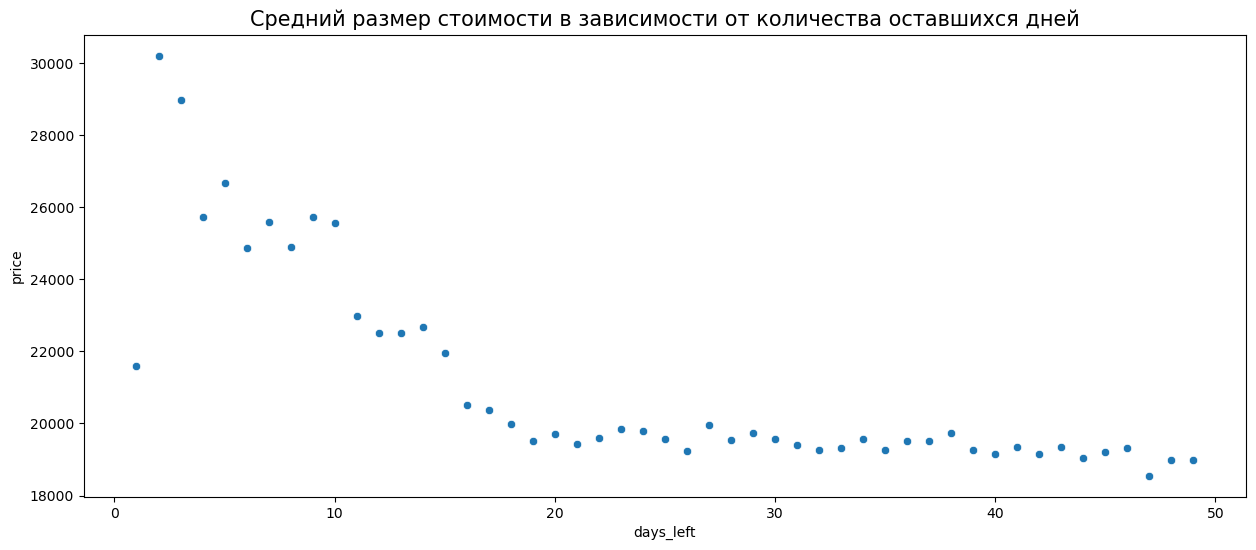

In [22]:
df_temp = df.groupby(['days_left'])['price'].mean().reset_index()

plt.figure(figsize=(15,6))
ax = sns.scatterplot(x="days_left", y="price", data=df_temp).set_title("Средний размер стоимости в зависимости от количества оставшихся дней",fontsize=15)

### Подготовка данных

In [23]:
print(df.dtypes)

airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object


In [24]:
print("\nКоличество уникальных значений в категориальных столбцах:")
cat_columns = df.select_dtypes(include=['object']).columns
print(df[cat_columns].nunique())


Количество уникальных значений в категориальных столбцах:
airline                6
flight              1561
source_city            6
departure_time         6
stops                  3
arrival_time           6
destination_city       6
class                  2
dtype: int64


In [25]:
categorical_columns = [
    'airline',
    'flight',
    'source_city',
    'departure_time',
    'stops',
    'arrival_time',
    'destination_city',
    'class'
]

label_mappings = {}

for col in categorical_columns:
    if col in df.columns:
        unique_values = df[col].unique()
        mapping = {val: idx for idx, val in enumerate(unique_values)}
        label_mappings[col] = mapping
        
        new_col_name = f'ID_{col}'
        df[new_col_name] = df[col].map(mapping)

In [26]:
print(df.head(10))

    airline   flight source_city departure_time stops   arrival_time  \
0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4   Vistara   UK-963       Delhi        Morning  zero        Morning   
5   Vistara   UK-945       Delhi        Morning  zero      Afternoon   
6   Vistara   UK-927       Delhi        Morning  zero        Morning   
7   Vistara   UK-951       Delhi      Afternoon  zero        Evening   
8  GO_FIRST   G8-334       Delhi  Early_Morning  zero        Morning   
9  GO_FIRST   G8-336       Delhi      Afternoon  zero        Evening   

  destination_city    class  duration  days_left  price  ID_airline  \
0           Mumbai  Economy      2.17          1   5953           0   
1           Mumbai  Economy      2.33          1   5953          

<Axes: >

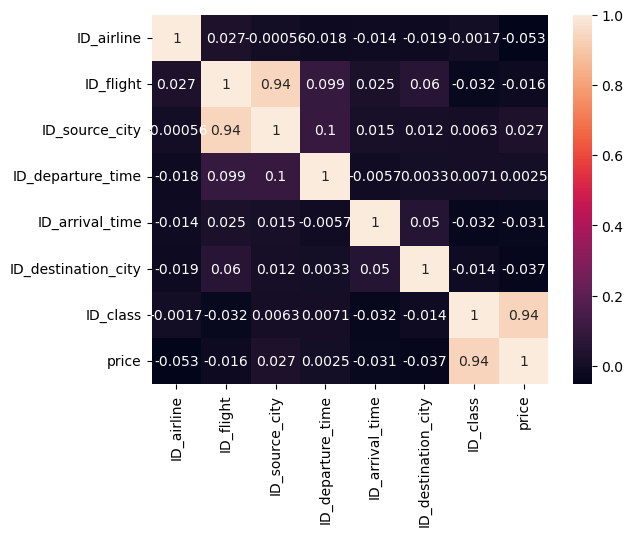

In [27]:
sns.heatmap(df[['ID_airline', 'ID_flight','ID_source_city','ID_departure_time','ID_arrival_time', 'ID_destination_city', 'ID_class', 'price']].corr(), annot=True)

Явная зависимость видна между ценой и классом - эконом класс дешевле, 1 класс дороже. Такая же явная зависимость есть между городом-источником и рейсом самолета

### Обучение модели линейной регрессии

In [28]:
df.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price', 'ID_airline', 'ID_flight', 'ID_source_city',
       'ID_departure_time', 'ID_stops', 'ID_arrival_time',
       'ID_destination_city', 'ID_class'],
      dtype='object')

In [29]:
X = df[['ID_airline', 'ID_flight','ID_source_city','ID_departure_time','ID_arrival_time', 'ID_destination_city', 'ID_class']]

In [30]:
y = df['price']

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Импорт всего нужного

In [33]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

### Линейная регрессия и другие модели

In [34]:
models = [
    ('Linear Regression', LinearRegression()),
    ('KNeighborsRegressor', KNeighborsRegressor()),
    ('DecisionTreeRegressor', DecisionTreeRegressor(random_state=42)),
    ('RandomForestRegressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
]
results = []

In [36]:
def print_metrics(y_true, y_pred, dataset='Test'):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f'{dataset} set evaluation:\n_____________________________________')
    print(f'MAE: {mae:.2f}')
    print(f'MSE: {mse:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R2 Square: {r2:.2f}')
    print('====================================')
    return mae, mse, rmse, r2

for name, model in models:
    model.fit(X_train, y_train)
    test_pred = model.predict(X_test)
    train_pred = model.predict(X_train)
    
    print(f'Model: {name}')
    mae_t, mse_t, rmse_t, r2_t = print_metrics(y_test, test_pred, 'Test')
    mae_tr, mse_tr, rmse_tr, r2_tr = print_metrics(y_train, train_pred, 'Train')
    
    results.append({
        'Model': name,
        'MAE': mae_t,
        'MSE': mse_t,
        'RMSE': rmse_t,
        'R2 Square': r2_t
    })

Model: Linear Regression
Test set evaluation:
_____________________________________
MAE: 4894.78
MSE: 59775341.15
RMSE: 7731.45
R2 Square: 0.88
Train set evaluation:
_____________________________________
MAE: 4925.47
MSE: 60180716.26
RMSE: 7757.62
R2 Square: 0.88
Model: KNeighborsRegressor
Test set evaluation:
_____________________________________
MAE: 2541.22
MSE: 19625503.49
RMSE: 4430.07
R2 Square: 0.96
Train set evaluation:
_____________________________________
MAE: 2426.37
MSE: 17404429.19
RMSE: 4171.86
R2 Square: 0.97
Model: DecisionTreeRegressor
Test set evaluation:
_____________________________________
MAE: 2349.35
MSE: 14672277.77
RMSE: 3830.44
R2 Square: 0.97
Train set evaluation:
_____________________________________
MAE: 2256.66
MSE: 13445897.31
RMSE: 3666.86
R2 Square: 0.97
Model: RandomForestRegressor
Test set evaluation:
_____________________________________
MAE: 2352.70
MSE: 14616462.07
RMSE: 3823.15
R2 Square: 0.97
Train set evaluation:
________________________________

### Сравнение моделей

In [38]:
results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,R2 Square
0,Linear Regression,4894.779519,5.977534e+07,7731.451426,0.883856
1,KNeighborsRegressor,2541.219161,1.962550e+07,4430.068114,0.961868
2,DecisionTreeRegressor,2349.345252,1.467228e+07,3830.440937,0.971492
3,RandomForestRegressor,2352.699310,1.461646e+07,3823.148188,0.971600
4,Linear Regression,4894.779519,5.977534e+07,7731.451426,0.883856
5,KNeighborsRegressor,2541.219161,1.962550e+07,4430.068114,0.961868
6,DecisionTreeRegressor,2349.345252,1.467228e+07,3830.440937,0.971492
7,RandomForestRegressor,2352.699310,1.461646e+07,3823.148188,0.971600


<Axes: ylabel='Model'>

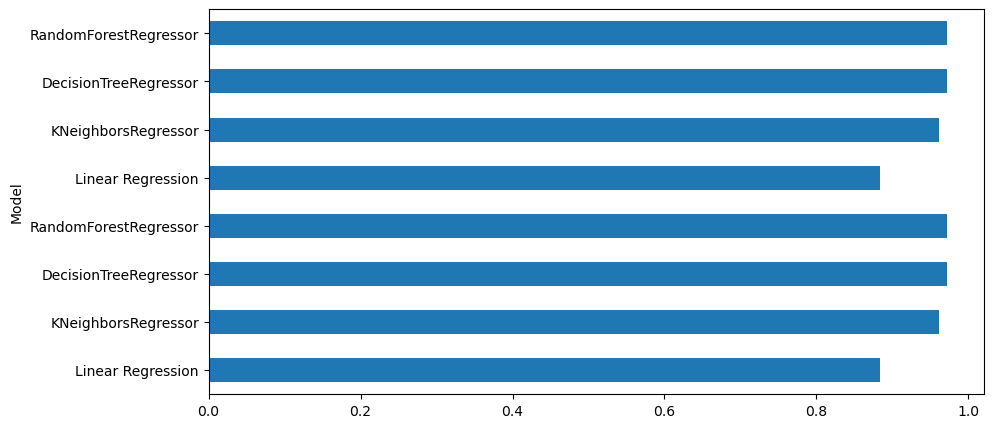

In [39]:
results_df.set_index('Model', inplace=True)
results_df['R2 Square'].plot(kind='barh', figsize=(10, 5))

### Масштабирование данных

Есть два основных вида масштабирования данных: нормализация и стандартизация.

### Нормализация

In [41]:
scaler_norm = MinMaxScaler()
X_train_norm = scaler_norm.fit_transform(X_train)
X_test_norm = scaler_norm.transform(X_test)

scaler_stand = StandardScaler()
X_train_stand = scaler_stand.fit_transform(X_train)
X_test_stand = scaler_stand.transform(X_test)

In [44]:
results_scaled = []

for scale_type, X_tr, X_te in [('Norm', X_train_norm, X_test_norm), ('Stand', X_train_stand, X_test_stand)]:
    for name, model in models:
        model.fit(X_tr, y_train)
        pred = model.predict(X_te)
        mae, mse, rmse, r2 = print_metrics(y_test, pred)
        results_scaled.append({
            'Model': name,
            'Scale': scale_type,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2 Square': r2
        })

Test set evaluation:
_____________________________________
MAE: 4894.78
MSE: 59775341.15
RMSE: 7731.45
R2 Square: 0.88
Test set evaluation:
_____________________________________
MAE: 2469.94
MSE: 17653285.77
RMSE: 4201.58
R2 Square: 0.97
Test set evaluation:
_____________________________________
MAE: 2349.19
MSE: 14670631.43
RMSE: 3830.23
R2 Square: 0.97
Test set evaluation:
_____________________________________
MAE: 2352.74
MSE: 14616395.57
RMSE: 3823.14
R2 Square: 0.97
Test set evaluation:
_____________________________________
MAE: 4894.78
MSE: 59775341.15
RMSE: 7731.45
R2 Square: 0.88
Test set evaluation:
_____________________________________
MAE: 2478.30
MSE: 17696667.32
RMSE: 4206.74
R2 Square: 0.97
Test set evaluation:
_____________________________________
MAE: 2349.19
MSE: 14670857.72
RMSE: 3830.26
R2 Square: 0.97
Test set evaluation:
_____________________________________
MAE: 2352.59
MSE: 14615459.87
RMSE: 3823.02
R2 Square: 0.97


In [45]:
results_df_scaled = pd.DataFrame(results_scaled)
results_df_scaled

,Model,Scale,MAE,MSE,RMSE,R2 Square
0,Linear Regression,Norm,4894.779519,5.977534e+07,7731.451426,0.883856
1,KNeighborsRegressor,Norm,2469.942931,1.765329e+07,4201.581341,0.965700
2,DecisionTreeRegressor,Norm,2349.192434,1.467063e+07,3830.226028,0.971495
3,RandomForestRegressor,Norm,2352.741299,1.461640e+07,3823.139491,0.971600
4,Linear Regression,Stand,4894.779519,5.977534e+07,7731.451426,0.883856
5,KNeighborsRegressor,Stand,2478.297819,1.769667e+07,4206.740700,0.965615
6,DecisionTreeRegressor,Stand,2349.194193,1.467086e+07,3830.255569,0.971494
7,RandomForestRegressor,Stand,2352.590142,1.461546e+07,3823.017116,0.971602


### Итоговая таблица с нормализацией и стандартизацией

In [47]:
results_final = pd.merge(results_df, results_df_scaled, on='Model', suffixes=('', '_scaled'))
results_final

,Model,MAE,MSE,RMSE,R2 Square,Scale,MAE_scaled,MSE_scaled,RMSE_scaled,R2 Square_scaled
0,Linear Regression,4894.779519,5.977534e+07,7731.451426,0.883856,Norm,4894.779519,5.977534e+07,7731.451426,0.883856
1,Linear Regression,4894.779519,5.977534e+07,7731.451426,0.883856,Stand,4894.779519,5.977534e+07,7731.451426,0.883856
2,KNeighborsRegressor,2541.219161,1.962550e+07,4430.068114,0.961868,Norm,2469.942931,1.765329e+07,4201.581341,0.965700
3,KNeighborsRegressor,2541.219161,1.962550e+07,4430.068114,0.961868,Stand,2478.297819,1.769667e+07,4206.740700,0.965615
4,DecisionTreeRegressor,2349.345252,1.467228e+07,3830.440937,0.971492,Norm,2349.192434,1.467063e+07,3830.226028,0.971495
5,DecisionTreeRegressor,2349.345252,1.467228e+07,3830.440937,0.971492,Stand,2349.194193,1.467086e+07,3830.255569,0.971494
6,RandomForestRegressor,2352.699310,1.461646e+07,3823.148188,0.971600,Norm,2352.741299,1.461640e+07,3823.139491,0.971600
7,RandomForestRegressor,2352.699310,1.461646e+07,3823.148188,0.971600,Stand,2352.590142,1.461546e+07,3823.017116,0.971602
8,Linear Regression,4894.779519,5.977534e+07,7731.451426,0.883856,Norm,4894.779519,5.977534e+07,7731.451426,0.883856
9,Linear Regression,4894.779519,5.977534e+07,7731.451426,0.883856,Stand,4894.779519,5.977534e+07,7731.451426,0.883856


Итоги
- Масштабирование данных нужно для более **стабильного** обучения модели.
- Есть два основных вида масштабирование
    1. ***Нормализация***
        - После min = 0, max = 1 у всех признаков
        - Подход лучше зарекомендовал себя в подходах МЛ, которые работают с расстояниями (KNN) 
    2. ***Стандартизация***
        - После mean = 0, std = 1 у всех признаков
        - Подход лучше зарекомендовал себя в линейных подходах МЛ (LinearRegression, SVM) 
- Для моделей, основанных на **дереве решений** (DecisionTree, Bagging, RandomForest, Boosting) масштабирование данных **необязательно**

In [51]:
# Ridge
model_ridge = Ridge(alpha=100, solver='cholesky', tol=0.0001, random_state=42)
model_ridge.fit(X_train, y_train)
print_metrics(y_test, model_ridge.predict(X_test), 'Test')
print_metrics(y_train, model_ridge.predict(X_train), 'Train')

print("-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-")
print("=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=")
print("-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-")

# Lasso
model_lasso = Lasso(alpha=0.1, precompute=True, positive=True, selection='random', random_state=42)
model_lasso.fit(X_train, y_train)
print_metrics(y_test, model_lasso.predict(X_test), 'Test')
print_metrics(y_train, model_lasso.predict(X_train), 'Train')

Test set evaluation:
_____________________________________
MAE: 4900.65
MSE: 59776337.91
RMSE: 7731.52
R2 Square: 0.88
Train set evaluation:
_____________________________________
MAE: 4931.60
MSE: 60182958.12
RMSE: 7757.77
R2 Square: 0.88
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
Test set evaluation:
_____________________________________
MAE: 4878.52
MSE: 61460769.58
RMSE: 7839.69
R2 Square: 0.88
Train set evaluation:
_____________________________________
MAE: 4913.54
MSE: 61957937.46
RMSE: 7871.34
R2 Square: 0.88


(4913.536028686848,
 61957937.45811892,
 np.float64(7871.336446761688),
 0.8797889887355586)

### ИТОГИ

**Регрессия** — это мощный и интерпретируемый инструмент для анализа зависимостей и прогнозирования. 

**Линейная регрессия** — базовый и самый важный метод. Современные методы (Ridge, Lasso) решают проблемы переобучения.

Преимущества:
- Интерпретируемость: Коэффициенты показывают, как факторы (длительность, дни до вылета) влияют на цену.
- Скорость: Быстрое обучение.
- Надежность: Теоретическое обоснование.

Недостатки:
- Чувствительность к нарушениям (мультиколлинеарность от категорий).
- Выбросы: Высокие цены на редкие рейсы могут искажать.
- Линейность: Не всегда захватывает нелинейные зависимости (например, спрос в пиковые часы).